# USD/JPY Fear & Greed Index — 段階1 検証ノートブック

CNN の Fear & Greed Index を **為替(USD/JPY)** に翻案した指数を構築・検証する。

- ① CNN 指数の解明 → [`docs/methodology_cnn.md`](../docs/methodology_cnn.md)
- ② USD/JPY 版の設計 → [`docs/methodology_usdjpy.md`](../docs/methodology_usdjpy.md)

**符号規約(リスク選好型)**: 高スコア = Greed = リスクオン = 円安 = USD/JPY 上昇 /
低スコア = Fear = リスクオフ = 円高 = USD/JPY 下落。極端な強欲はキャリー過熱・反転リスクの警告も兼ねる。

**6 構成要素**: モメンタム / 52週レンジ位置 / 実現ボラ(通貨VIX) / 日米金利差 / クロスアセット・リスク / CFTC建玉。
すべて無料データ(yfinance・米財務省・財務省JGB・CFTC)。

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib
matplotlib.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True})
from data_sources.load import build_dataset
from fng.index import compute_index, snapshot, label_for
from config import CONFIG
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
print("setup OK")

setup OK


## 1. データ取得 → 日次グリッドに統合
`build_dataset()` が yfinance(価格)・米財務省 + 財務省JGB(金利)・CFTC(建玉)を USD/JPY の営業日に整列する。

In [2]:
df = build_dataset("USDJPY", start="2019-01-01", force=False)
print("rows:", len(df), " range:", df.index.min().date(), "->", df.index.max().date())
print("non-null:\n", df.notna().sum().to_string())
df.tail(3)

rows: 1945  range: 2019-01-01 -> 2026-06-23
non-null:
 price          1945
vix            1944
sp500          1944
nikkei         1941
audjpy         1945
gold           1944
base_2y        1944
base_10y       1944
quote_2y       1942
quote_10y      1942
cot_signal     1940
breadth_pct    1945


,price,vix,sp500,nikkei,audjpy,gold,base_2y,base_10y,quote_2y,quote_10y,cot_signal,breadth_pct
date,,,,,,,,,,,,
2026-06-19,161.289001,16.400000,7500.580078,71250.062500,113.103996,4224.100098,4.19,4.46,1.393,2.657,-992.0,0.333333
2026-06-22,161.432999,17.280001,7472.790039,72353.960938,113.039001,4181.899902,4.24,4.51,1.393,2.657,-992.0,0.166667
2026-06-23,161.570007,19.490000,7365.459961,69788.382812,113.004997,4129.899902,4.16,4.50,1.393,2.657,-992.0,0.166667


## 2. 最新スナップショット(headline + 6要素内訳)

In [3]:
snap = snapshot(df)
print(f"日付: {snap['date']}")
print(f"USD/JPY: {snap['price']}")
print(f"Fear & Greed: {snap['fear_greed']}  [{snap['label_en']} / {snap['label_ja']}]")
print(f"実現ボラ(年率): {snap['realized_vol_pct']}%")
print("--- 構成要素(0-100, 高=Greed) ---")
for k, v in snap['components'].items():
    bar = "#" * int((v or 0) / 5)
    print(f"  {k:13s} {('--' if v is None else format(v,'5.1f'))}  {bar}")
snap

日付: 2026-06-23
USD/JPY: 161.57
Fear & Greed: 63.7  [Greed / 強欲]
実現ボラ(年率): 2.41%
--- 構成要素(0-100, 高=Greed) ---
  momentum       59.3  ###########
  strength      100.0  ####################
  realized_vol   95.4  ###################
  rate_diff      67.8  #############
  risk_regime    39.9  #######
  cot            52.8  ##########
  breadth         7.9  #


{'pair': 'USDJPY',
 'date': '2026-06-23',
 'fear_greed': 63.7,
 'label_en': 'Greed',
 'label_ja': '強欲',
 'components': {'momentum': 59.3,
  'strength': 100.0,
  'realized_vol': 95.4,
  'rate_diff': 67.8,
  'risk_regime': 39.9,
  'cot': 52.8,
  'breadth': 7.9},
 'price': 161.57,
 'realized_vol_pct': 2.41}

## 3. 指数の全history(2019–) と USD/JPY
F&G は percentile ベースの **平均回帰オシレーター**。USD/JPY が長期上昇しても指数は 0–100 を振動する(価格追従ではなくセンチメント計)。

headline stats: {'min': 3.0, 'mean': 51.7, 'max': 95.9}


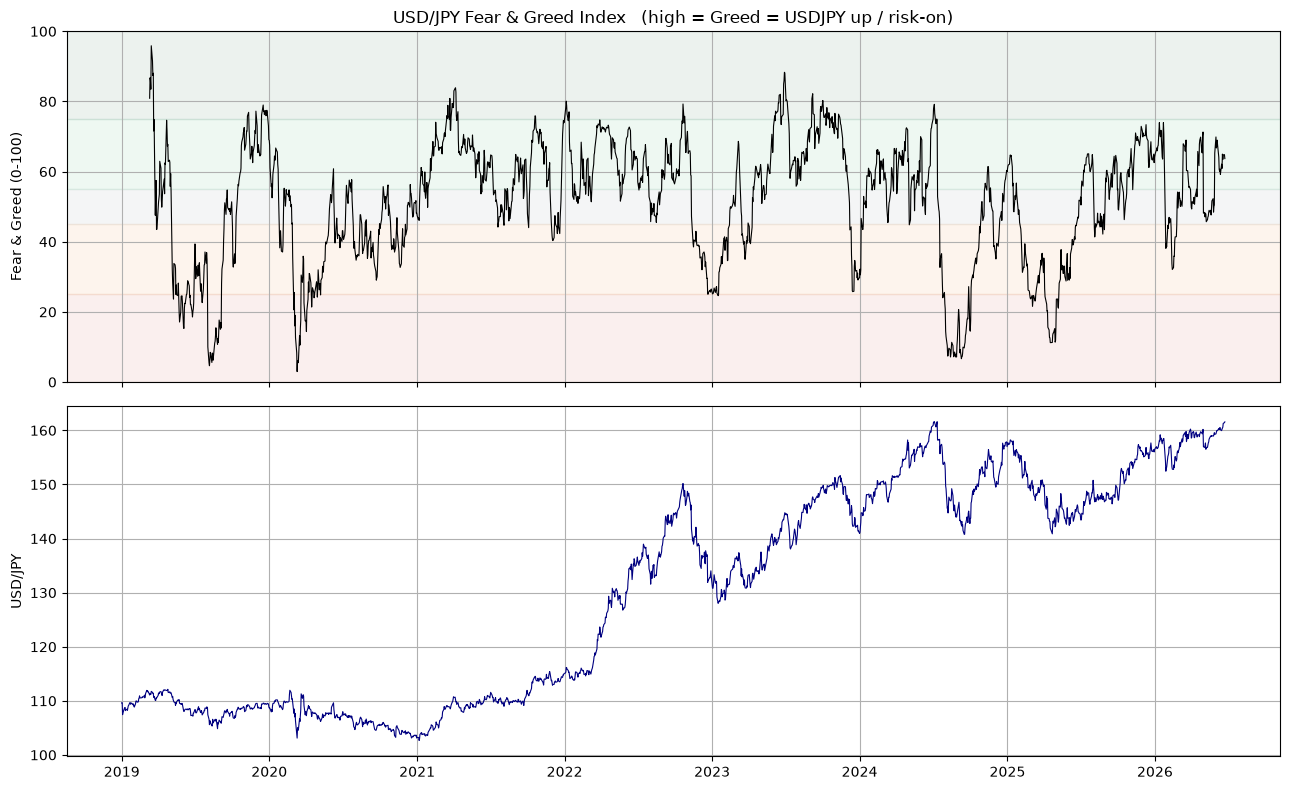

In [4]:
res = compute_index(df)
print("headline stats:", res['fear_greed'].describe()[['min','mean','max']].round(1).to_dict())

fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax[0].plot(res.index, res['fear_greed'], lw=0.8, color='black')
for lo, hi, c in [(0,25,'#c0392b'),(25,45,'#e67e22'),(45,55,'#7f8c8d'),(55,75,'#27ae60'),(75,100,'#145a32')]:
    ax[0].axhspan(lo, hi, alpha=0.08, color=c)
ax[0].set_ylim(0,100); ax[0].set_ylabel('Fear & Greed (0-100)')
ax[0].set_title('USD/JPY Fear & Greed Index   (high = Greed = USDJPY up / risk-on)')
ax[1].plot(df.index, df['price'], lw=0.8, color='navy'); ax[1].set_ylabel('USD/JPY')
plt.tight_layout(); plt.show()

## 4. 構成要素の現在内訳

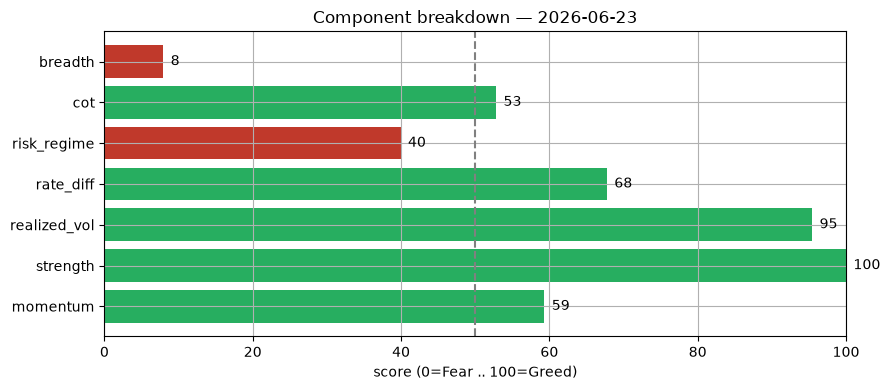

In [5]:
names = list(CONFIG['components'].keys())
latest = res[names].dropna(how='all').iloc[-1]
colors = ['#27ae60' if v>=50 else '#c0392b' for v in latest]
fig, a = plt.subplots(figsize=(9,4))
a.barh(names, latest.values, color=colors)
a.axvline(50, color='gray', ls='--'); a.set_xlim(0,100)
a.set_xlabel('score (0=Fear .. 100=Greed)'); a.set_title(f"Component breakdown — {res.index[-1].date()}")
for i,v in enumerate(latest.values): a.text(v+1, i, f"{v:.0f}", va='center')
plt.tight_layout(); plt.show()

## 5. ケーススタディ: 2024年8月のキャリー巻き戻し
円キャリー解消で USD/JPY が暴落した局面。符号規約が正しければ指数は **強欲 → 極度の恐怖** へ急落するはず。

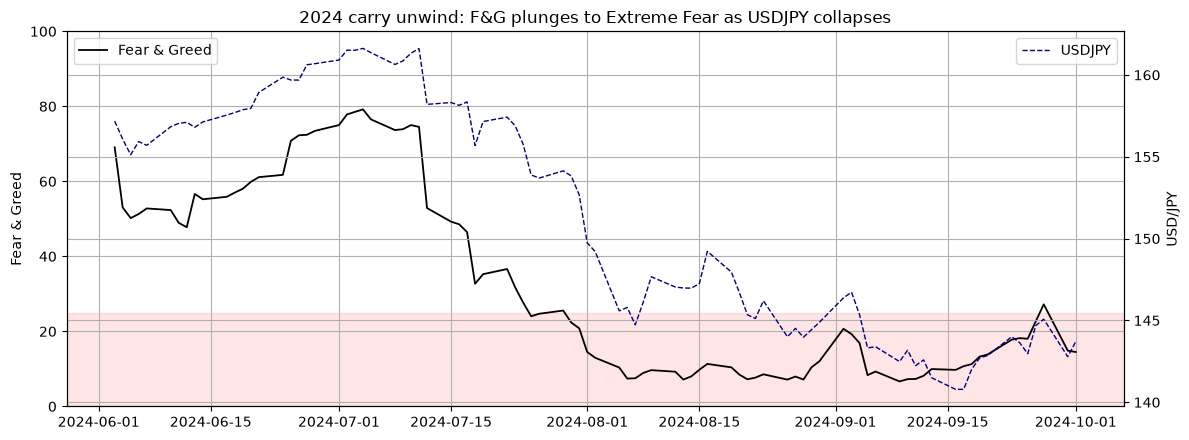

window min F&G: 6.7 on 2024-09-09
early-July peak F&G: 79.2


In [6]:
z = res.loc['2024-06-01':'2024-10-01']; zp = df.loc['2024-06-01':'2024-10-01','price']
fig, a = plt.subplots(figsize=(12,4.5))
a.plot(z.index, z['fear_greed'], color='black', lw=1.3, label='Fear & Greed')
a.axhspan(0,25,alpha=0.1,color='red'); a.set_ylim(0,100); a.set_ylabel('Fear & Greed')
a2 = a.twinx(); a2.plot(zp.index, zp.values, color='navy', ls='--', lw=1, label='USDJPY'); a2.set_ylabel('USD/JPY')
a.set_title('2024 carry unwind: F&G plunges to Extreme Fear as USDJPY collapses')
a.legend(loc='upper left'); a2.legend(loc='upper right'); plt.tight_layout(); plt.show()
print('window min F&G:', round(z['fear_greed'].min(),1), 'on', z['fear_greed'].idxmin().date())
print('early-July peak F&G:', round(z.loc[:'2024-07-10','fear_greed'].max(),1))

## 6. 通貨VIX(USD/JPY 実現ボラティリティ)
無料の FX インプライドボラ源が無いため、20日実現ボラ(年率)を「通貨VIX」とする。`^VIX`(株式)を文脈として併記。

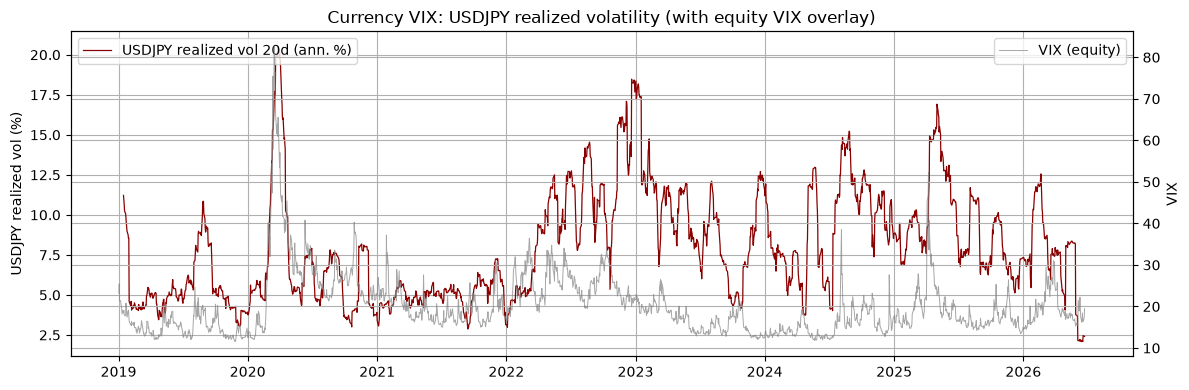

現在の実現ボラ: 2.4%  (1年percentile 4 -> Calm)


In [7]:
rv = res['realized_vol_pct']
fig, a = plt.subplots(figsize=(12,4))
a.plot(rv.index, rv.values, color='darkred', lw=0.9, label='USDJPY realized vol 20d (ann. %)')
a.set_ylabel('USDJPY realized vol (%)');
a2 = a.twinx(); a2.plot(df.index, df['vix'], color='gray', lw=0.7, alpha=0.7, label='VIX (equity)')
a2.set_ylabel('VIX')
a.set_title('Currency VIX: USDJPY realized volatility (with equity VIX overlay)')
a.legend(loc='upper left'); a2.legend(loc='upper right'); plt.tight_layout(); plt.show()
cur = rv.dropna().iloc[-1]; pctl = (rv.dropna().tail(252) < cur).mean()*100
regime = 'Calm' if pctl < 33 else ('Stressed' if pctl > 66 else 'Normal')
print(f"現在の実現ボラ: {cur:.1f}%  (1年percentile {pctl:.0f} -> {regime})")

## 7. まとめ・次のステップ

- 6 要素すべてが無料データで稼働。2024年8月の巻き戻しで **強欲→極度の恐怖** を正しく再現(符号規約OK)。
- **限界**: 実現ボラは終値ベース(日中レンジ過小評価)、無料の FX インプライドボラ/リスクリバーサル(スキュー)が無い。
- **段階2**: 本ノートのロジック(`fng/`・`data_sources/`)をそのまま Streamlit ダッシュボード化
  (headlineダイヤル + 6要素バー + 通貨VIXカード + 現在値/MA + 1週/1月/1年比較)。
- **段階3**: 他通貨ペアへ拡張(`config.py` にペア定義を追加)、JPY-strength breadth 要素、(予算次第で)インプライドボラ高度化。

CLI でも当日値を取得可能:
```
.venv/bin/python -m fng.index --pair USDJPY
```